In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

In [2]:
log_path = "./tests/run_parallel/logs400/"
all_results = []

## Melhor valor de Best_Improvement

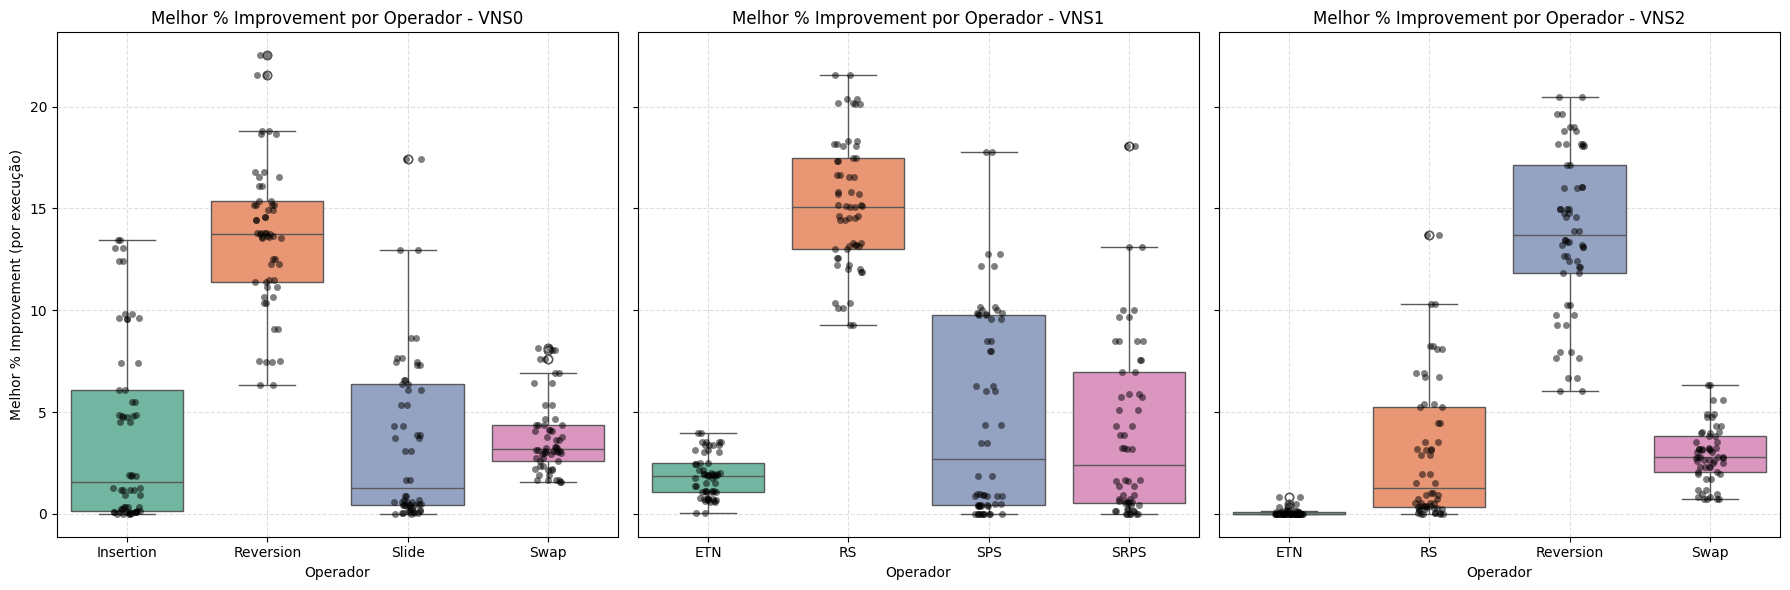

In [4]:
# Para cada método (VNS0, VNS1, VNS2)
for method in range(3):
    csv_files = glob.glob(os.path.join(log_path, f"VNS{method}_*.csv"))
    
    for f in csv_files:
        df = pd.read_csv(f)
        df["Execution"] = os.path.splitext(os.path.basename(f))[0]
        df["Method"] = f"VNS{method}"
        
        # Pegar o melhor % Improvement por operador
        best_per_operator = df.groupby("Operator")["% Improvement"].max().reset_index()
        best_per_operator["Method"] = f"VNS{method}"
        best_per_operator["Execution"] = os.path.splitext(os.path.basename(f))[0]
        
        all_results.append(best_per_operator)

# Juntar tudo
df_all = pd.concat(all_results, ignore_index=True)

# Garantir que está numérico
df_all["% Improvement"] = pd.to_numeric(df_all["% Improvement"], errors="coerce")

# Preparar subplots
methods = df_all["Method"].unique()
num_methods = len(methods)

fig, axes = plt.subplots(1, num_methods, figsize=(6* num_methods, 6), sharey=True)

# Agora, para cada método, plotar no subplot correspondente
for method, ax in zip(methods, axes):
    subset = df_all[df_all["Method"] == method]
    
    sns.boxplot(data=subset, x="Operator", y="% Improvement", hue="Operator", palette="Set2", dodge=False, legend=False, ax=ax)
    sns.stripplot(data=subset, x="Operator", y="% Improvement", color="black", alpha=0.5, jitter=True, ax=ax)
    
    ax.set_title(f'Melhor % Improvement por Operador - {method}')
    ax.set_xlabel("Operador")
    if method == methods[0]:
        ax.set_ylabel("Melhor % Improvement (por execução)")
    else:
        ax.set_ylabel("")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [5]:
for method in range(3):
    csv_files = glob.glob(os.path.join(log_path, f"VNS{method}_*.csv"))
    
    for f in csv_files:
        df = pd.read_csv(f)
        df["Execution"] = os.path.splitext(os.path.basename(f))[0]
        df["Method"] = f"VNS{method}"

        # Ordenar por número de avaliações (progresso do algoritmo)
        df = df.sort_values(by="Evaluations").reset_index(drop=True)
        
        # Dividir em 4 partes (quartis de tempo)
        quartil_labels = ['Q1', 'Q2', 'Q3', 'Q4']
        df['Quartil'] = np.concatenate([
            np.repeat(label, len(split)) for label, split in zip(quartil_labels, np.array_split(df.index, 4))
        ])

        # Para cada quartil, pegar o melhor % improvement por operador
        for quartil in quartil_labels:
            quartil_df = df[df["Quartil"] == quartil]
            best_per_operator = quartil_df.groupby("Operator")["% Improvement"].max().reset_index()
            best_per_operator["Method"] = f"VNS{method}"
            best_per_operator["Execution"] = os.path.splitext(os.path.basename(f))[0]
            best_per_operator["Quartil"] = quartil
            
            all_results.append(best_per_operator)
        
# Junta tudo
df_all = pd.concat(all_results, ignore_index=True)
df_all["% Improvement"] = pd.to_numeric(df_all["% Improvement"], errors="coerce")

# Gera 4 subplots (2x2) por método
methods = df_all["Method"].unique()
quartis = ['Q1', 'Q2', 'Q3', 'Q4']

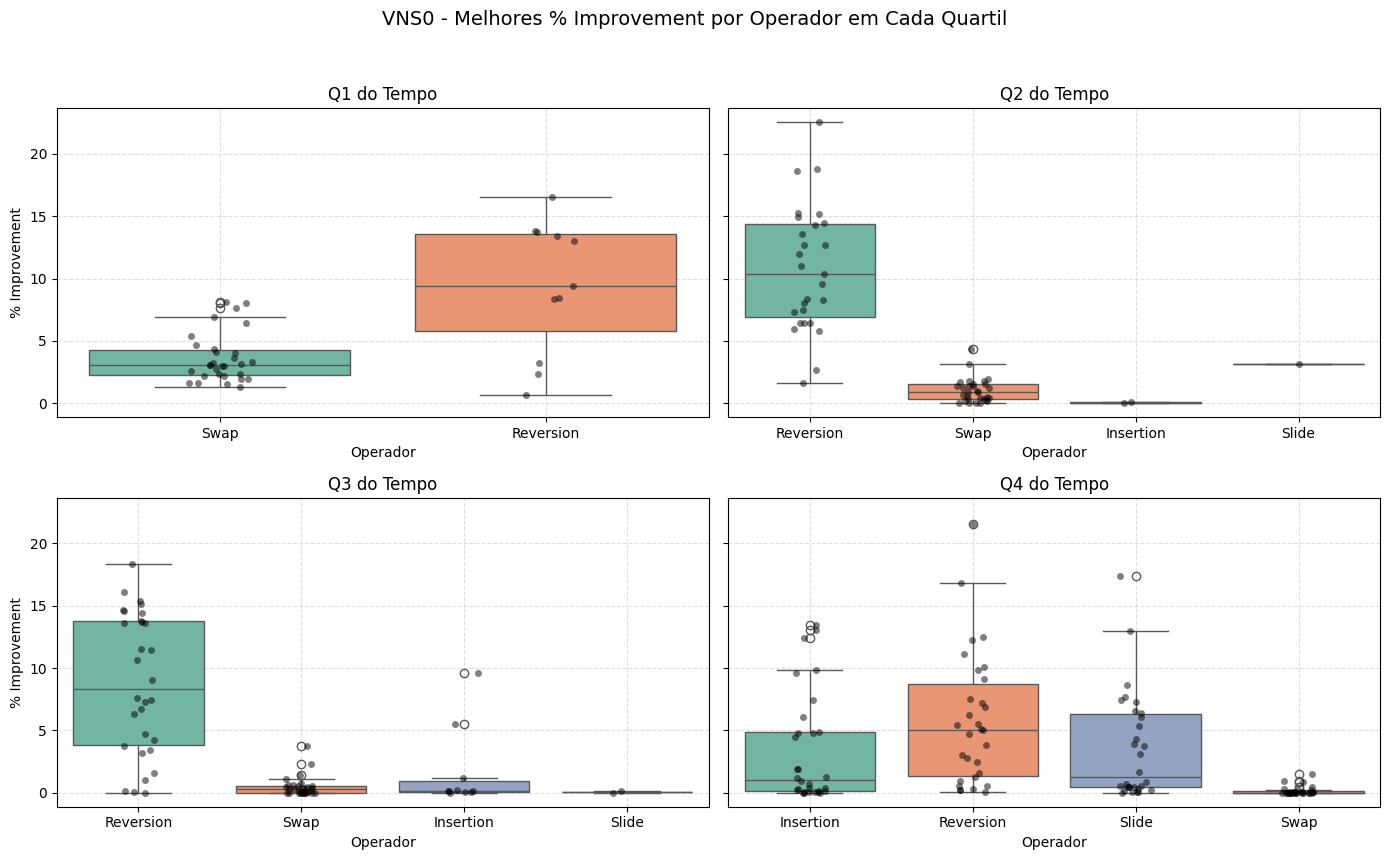

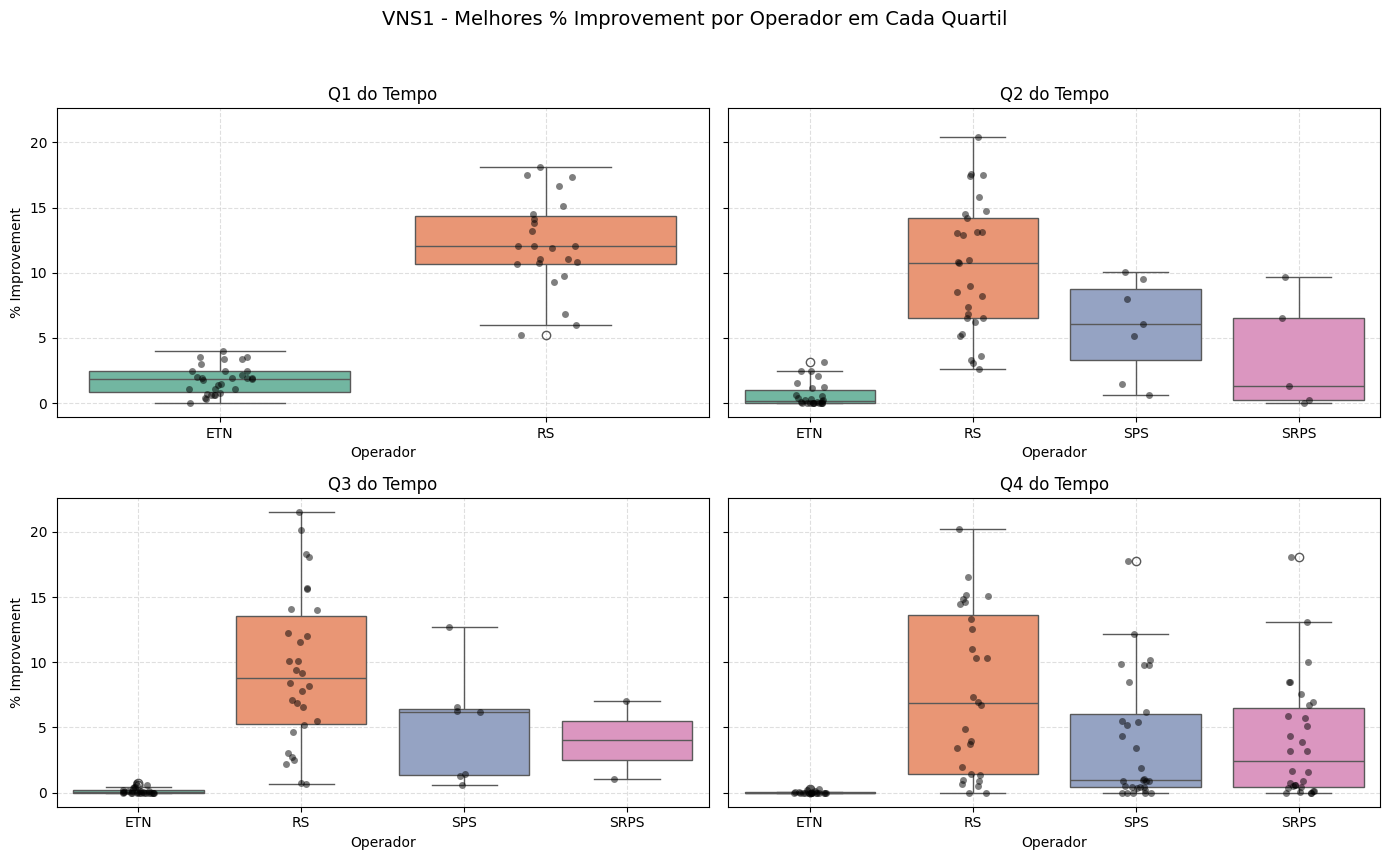

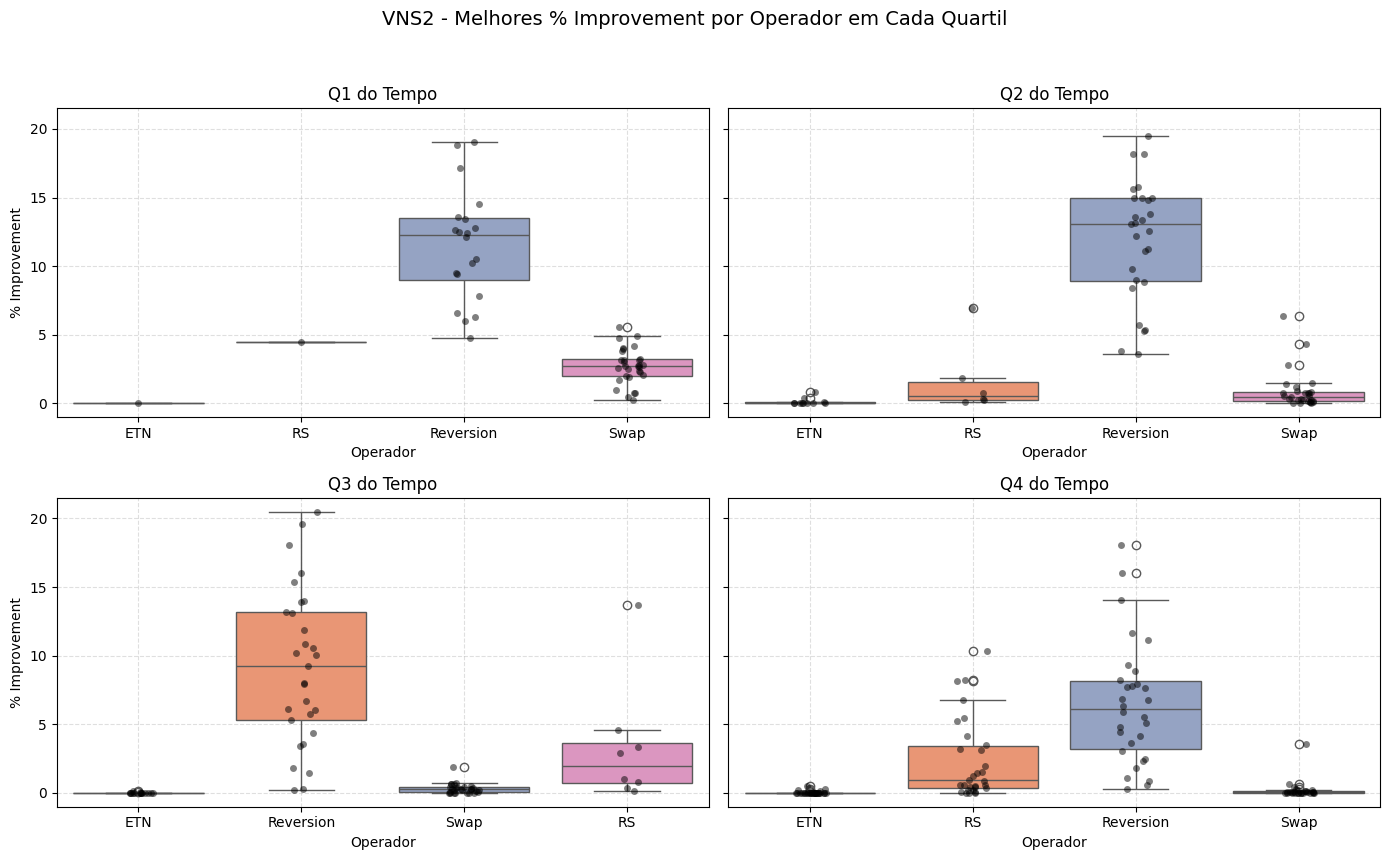

In [6]:
for method in methods:
    fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
    fig.suptitle(f'{method} - Melhores % Improvement por Operador em Cada Quartil', fontsize=14)
    
    for i, quartil in enumerate(quartis):
        row, col = divmod(i, 2)
        ax = axs[row, col]
        subset = df_all[(df_all["Method"] == method) & (df_all["Quartil"] == quartil)]

        sns.boxplot(data=subset, x="Operator", y="% Improvement", hue="Operator", palette="Set2", dodge=False, legend=False, ax=ax)
        sns.stripplot(data=subset, x="Operator", y="% Improvement", color="black", alpha=0.5, jitter=True, ax=ax)

        ax.set_title(f'{quartil} do Tempo')
        ax.set_xlabel("Operador")
        ax.set_ylabel("% Improvement")
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Deixa espaço para o título
    plt.show()

## Todos os valores de Best_Improvement

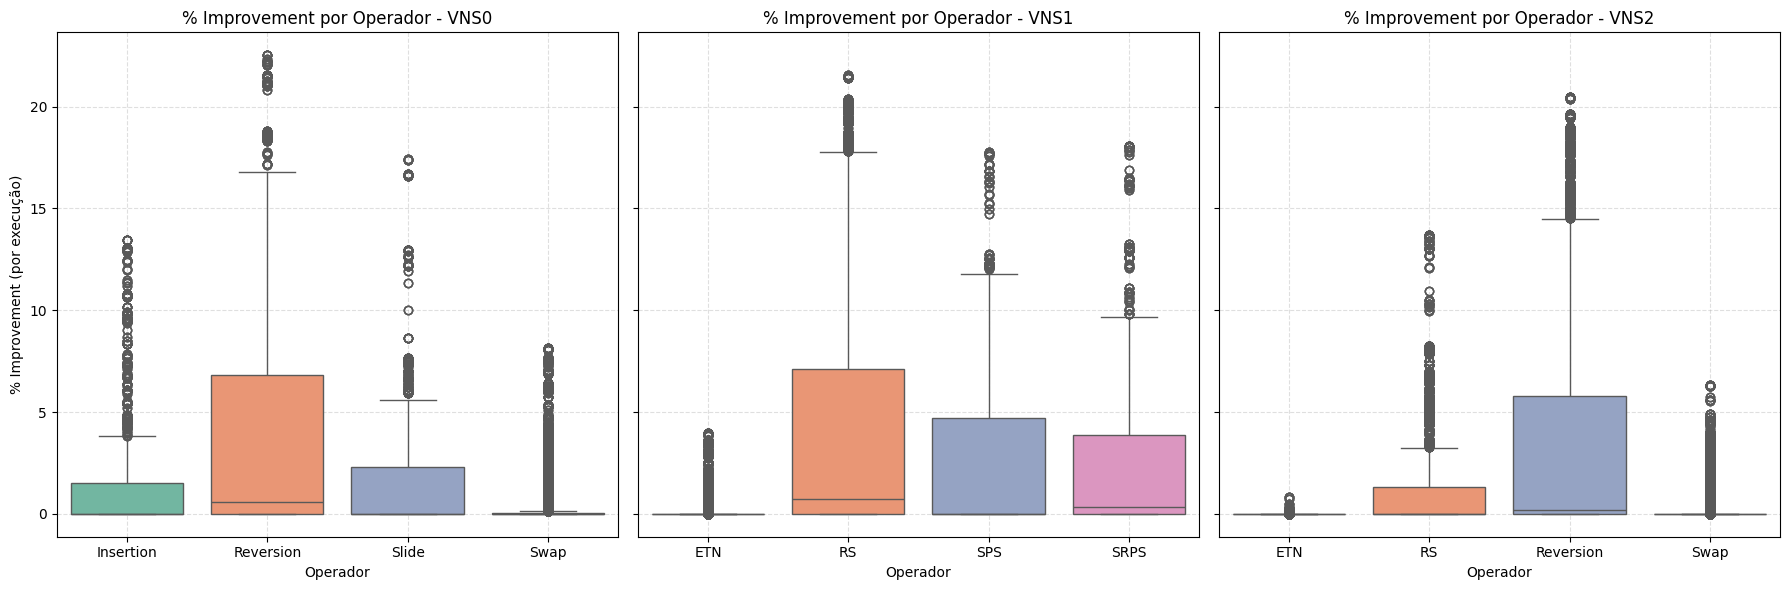

In [7]:
# Para cada método (VNS0, VNS1, VNS2)
for method in range(3):
    csv_files = glob.glob(os.path.join(log_path, f"VNS{method}_*.csv"))
    
    for f in csv_files:
        df = pd.read_csv(f)
        df["Execution"] = os.path.splitext(os.path.basename(f))[0]
        df["Method"] = f"VNS{method}"
        
        # Em vez de agrupar e pegar o max, salva TODOS os dados
        all_results.append(df[["Operator", "% Improvement", "Method", "Execution"]])

# Juntar tudo
df_all = pd.concat(all_results, ignore_index=True)

# Garantir que está numérico
df_all["% Improvement"] = pd.to_numeric(df_all["% Improvement"], errors="coerce")

# Preparar subplots
methods = df_all["Method"].unique()
num_methods = len(methods)

fig, axes = plt.subplots(1, num_methods, figsize=(6 * num_methods, 6), sharey=True)

if num_methods == 1:
    axes = [axes]

# Para cada método, plotar no subplot correspondente
for method, ax in zip(methods, axes):
    subset = df_all[df_all["Method"] == method]
    
    sns.boxplot(
        data=subset,
        x="Operator",
        y="% Improvement",
        hue="Operator",
        palette="Set2",
        dodge=False,
        legend=False,
        ax=ax
    )
    
    ax.set_title(f'% Improvement por Operador - {method}')
    ax.set_xlabel("Operador")
    if method == methods[0]:
        ax.set_ylabel("% Improvement (por execução)")
    else:
        ax.set_ylabel("")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()